# Лабораторна робота №4

Виконавець:  <b>Потєхіна Валерія Ігорівна</b>, група <b>К-27</b>
<br> Викладач: <b>Скибицький М.</b>

# Задача 2
У завданні 4 лабораторної роботи №2 оброблялися значення функції у точках. Побудувати графік цієї функції (кусково-лінійне наближення). На тому самому зображенні іншим кольором побудувати графік знайденої в результаті обчислень функції.

In [1]:
import pandas as pd
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt


Зчитаємо результати експерементів із CVS-файлу та агрегації даних.

Обчислимо середній час t для кожного розміру вхідних даних n.

In [2]:
raw = pd.read_csv('lab2_var119.csv')

task4 = raw.groupby('n')['t'].mean().reset_index()

n_exp = task4['n']
t_exp = task4['t']

Логарифмуємо дані та використаємо метод найменших квадратів (МНК) для оцінки параметрів a та c функції $T(n) = c \cdot n^a$.

In [3]:
task4['log n'] = np.log(task4['n'])
task4['log t'] = np.log(task4['t'])
task4['ones'] = 1

X = task4[['ones', 'log n']].to_numpy()
Y = task4['log t'].to_numpy()

res = la.lstsq(X, Y)[0]

a = res[1]
c = np.exp(res[0])

print(f"Знайдені параметри: c = {c:.6f}, a = {a:.6f}")

Знайдені параметри: c = 3.682521, a = 0.691405



Генеруємо масив точок scale для побудови гладкого графіка теоретично оціненої функції за знайденими параметрами.

In [4]:
scale = np.linspace(n_exp.min(), n_exp.max(), 100)
times = c * (scale ** a)


Будуємо обидва графіки на одному зображенні: кусково-лінійне наближення для експериментальних даних та гладка крива для оціненої функції.

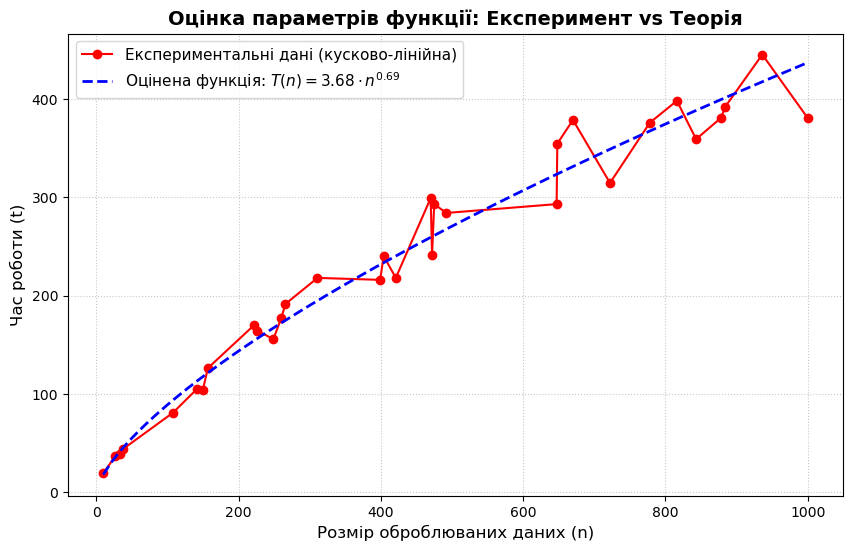

In [5]:
plt.figure(figsize=(10, 6))

plt.plot(n_exp, t_exp, color='red', marker='o', linestyle='-',
         label='Експериментальні дані (кусково-лінійна)')

plt.plot(scale, times, color='blue', linestyle='--',
         linewidth=2, label=rf'Оцінена функція: $T(n) = {c:.2f} \cdot n^{{{a:.2f}}}$')

plt.title('Оцінка параметрів функції: Експеримент vs Теорія', fontsize=14, fontweight='bold')
plt.xlabel('Розмір оброблюваних даних (n)', fontsize=12)
plt.ylabel('Час роботи (t)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)

plt.savefig('plot_task2.png', dpi=150, bbox_inches='tight')
plt.show()